# Analysis of MS proteomics Ependymoma dataset
> SysBio MS Proteomics course 2026
>
> By Ian Dirk Fichtner, Dennis Friedel and Rushda Patel
> 
> Neuropathology Department Heidelberg

## Tutorial overview

This tutorial walks through a complete computational mass-spectrometry (MS) proteomics analysis on a ependymoma cohort. We start from the [DIA-NN](https://github.com/vdemichev/DiaNN) search-engine output (precursor-level `report.parquet`) and end with biological interpretation via gene-set enrichment.

**Core pipeline**

1. **Read in DIA-NN output** and assemble a sample × protein matrix.
2. **Quality control** — drop contaminants, low-coverage samples, and sparsely measured proteins.
3. **Preprocessing** — log2 transform, median-normalize, impute missing values.
4. **Exploratory analysis** — sample correlation, PCA, UMAP.
5. **Differential protein abundance** — t-test between tumor classes.
6. **Pathway-level interpretation** — gene-set enrichment with `decoupler` against MSigDB.


**📝 Your-turn prompts**

Throughout the notebook you will see blockquotes marked with a 📝 emoji and the label *Your turn*. Each one sits directly below a plot or output and asks you to **interpret what you see** — pause, look at the figure, write down a short answer before scrolling on. Discussing with a neighbour is encouraged.

## Setup

> 📂 *Before you start*: this notebook expects you to load input files. It is recommended to save place them in a `data/` directory next at the project root. Place the following files there before running the cells below:
>
> - `data/report.parquet` — DIA-NN precursor-level search output.
> - `data/prot_anno.csv` — sample annotation (`sample_id` + `group` columns).
>
> The first code cell `cd`s up to the project root, so all paths below are written relative to it (e.g. `data/report.parquet`).

### A note on `proteopy` and `AnnData`

[`proteopy`](https://proteopy.readthedocs.io/) is a Python toolbox for MS proteomics analysis based on the [`AnnData`](https://anndata.readthedocs.io/) class. It exposes the analysis stages as submodules:

- `pr.read` — generic long-format tables.
- `pr.pp` — preprocessing (contaminant removal, filtering, normalization, imputation).
- `pr.pl` — plots.
- `pr.tl` — analytical tools (e.g. differential abundance).
- `pr.get` — accessors that pull results back out as tidy data frames.
- `pr.ann` — sample/feature annotation helpers.
- `pr.download` — fetch reference resources (e.g. contaminant FASTAs).

All data live inside an [`AnnData`](https://anndata.readthedocs.io/) object. AnnData has a small set of well-defined slots:

- `.X` — the main matrix; here **samples × proteins**.
- `.obs` — a data frame of per-sample (observation) metadata.
- `.var` — a data frame of per-protein (variable) metadata.
- `.layers` — alternative matrices of the same shape as `.X` (e.g. raw vs. log-transformed intensities).
- `.varm` / `.obsm` — multi-dimensional annotations per variable / observation. We will store differential-abundance results in `.varm`.
- `.uns` — unstructured annotations.

We will print the AnnData object right after reading in the data so you can see this structure for yourself.


> 🔥 *Reference*: every `proteopy` function used below is documented in the [API reference](https://proteopy.readthedocs.io/en/latest/api/index.html). Keep it open in a tab — when something is unclear, you can find useful information here.

In [1]:
import os
import sys
import random
from pathlib import Path

import anndata as ad
import proteopy as pr
import scanpy as sc
import decoupler as dc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns

random.seed(42)

cwd = Path('.').resolve()
root = cwd.parent
os.chdir(root)

sys.path.append(str(root / 'code'))


/home/ifichtner/miniforge3/envs/pp-usage_main/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/ifichtner/miniforge3/envs/pp-usage_main/lib/python3.10/site-packages
  warnings.warn(


## Read in and format the data

### What does DIA-NN give us?

[DIA-NN](https://github.com/vdemichev/DiaNN) is a search engine for **data-independent acquisition (DIA)** mass spectrometry. For every MS run it reports — in long format — every precursor it identified, together with quantitative values, several false-discovery-rate (FDR) statistics and protein-level annotations.

Relevant columns we load:

- `Run` — the MS run / sample.
- `Protein.Ids`, `Protein.Group`, `Genes`, `Protein.Names` — protein identifiers. A **protein group** is a set of proteins that share the same peptide evidence and therefore cannot be told apart by MS alone.
- `PG.MaxLFQ` — the label-free quantification value from the MaxLFQ algorithm; this is the per-run intensity we will use.
- `Q.Value`, `Protein.Q.Value`, `Global.Q.Value` — FDR statistics at different levels (precursor in run, protein in run, protein across experiment). We will filter precursors based on these statistics.

We then collapse the long table to a sample × protein matrix with `pr.read.long` which will serve as input for the `proteopy` reader function.

In [2]:
PARQUET_PATH = "data/report.parquet"
METADATA_PATH = "data/anno.csv"

In [3]:
df_raw = pd.read_parquet(
    PARQUET_PATH,
    columns=["Run", "Protein.Ids", "Protein.Group", "Genes", "Protein.Names",
             "PG.MaxLFQ", "Q.Value", "Protein.Q.Value", "Global.Q.Value"],
)

df_filt = (
    df_raw[
        (df_raw["Q.Value"] <= 0.01) &
        (df_raw["Protein.Q.Value"] <= 0.01) &
        (df_raw["Global.Q.Value"] <= 0.01) &
        (df_raw["PG.MaxLFQ"].notna()) &
        (df_raw["PG.MaxLFQ"] > 0)
    ]
    .drop_duplicates(subset=["Run", "Protein.Ids"])
)

print(f"Rows after filtering: {len(df_filt)}")

df_long = df_filt[["Run", "Protein.Ids", "PG.MaxLFQ"]].copy()
df_long.columns = ["sample_id", "protein_id", "intensity"]

var_annot = (
    df_filt.drop_duplicates("Protein.Ids")
    [["Protein.Ids", "Protein.Group", "Genes", "Protein.Names"]]
    .rename(columns={"Protein.Ids": "protein_id"})
)

adata = pr.read.long(
    df_long,
    level="protein",
    var_annotation=var_annot,
    fill_na=0,
    verbose=True,
)

adata

... storing 'Protein.Group' as categorical
... storing 'Genes' as categorical


Rows after filtering: 379437


... storing 'Protein.Names' as categorical


AnnData object with n_obs × n_vars = 54 × 10796
    obs: 'sample_id'
    var: 'protein_id', 'Protein.Group', 'Genes', 'Protein.Names'

Notice the printout above: 54 samples × 10,796 proteins. `.obs` carries the sample-level metadata column we just gave it (`sample_id`), and `.var` carries the four protein-level columns we passed via `var_annotation`. From here on, every step adds to or filters this object.

In [4]:
# Merge sample-level annotations
obs_ann = pd.read_csv(METADATA_PATH)

pr.ann.samples(
    adata,
    df=obs_ann,
    obs_on='sample_id',
    df_on='sample_id',
)

adata

AnnData object with n_obs × n_vars = 54 × 10796
    obs: 'sample_id', 'sample_id_annotated', 'group', 'group3'
    var: 'protein_id', 'Protein.Group', 'Genes', 'Protein.Names'

In [5]:
# Rename the group column for convenience
adata.obs = adata.obs.rename(columns={'group': 'tumor_class'})

adata.obs_names = adata.obs['sample_id'].astype(str)

## Quality control and preprocessing

First, we visualize the number of samples we have per tumor class.

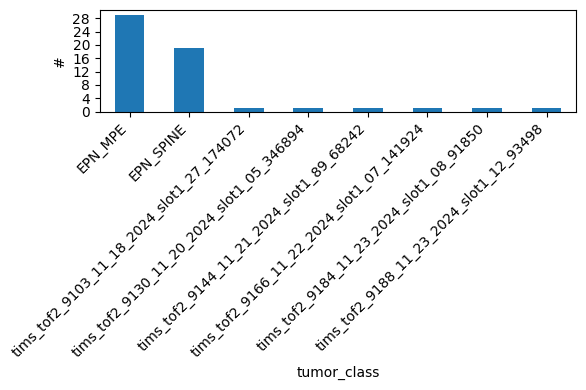

In [6]:
pr.pl.n_samples_per_category(adata, category_key=["tumor_class"])

> 📝 *Your turn*: Do we have enough samples for a two-group comparison? Are the tumor classes balanced?

<details>
<summary>Answer</summary>

The cohort spans several tumor classes; only the two with the largest *n* (here `EPN_MPE` and `EPN_SPINE`) are suitable for a parametric two-group test. A handful of classes are represented by 1–2 samples and we will drop them from the differential analysis — a t-test on n=2 has essentially no power and any "significant" result would be noise.

The two main groups are not perfectly balanced but are within a 2–3× ratio of each other, which is fine for a Welch t-test (it does not assume equal sample sizes or equal variance).

</details>

#### Contaminant removal

Sample preparation introduces non-biological proteins: keratins from skin/hair, trypsin used for digestion, BSA from buffers, etc. These co-purify with the sample and produce strong, sample-independent signals that can dominate downstream analysis if left in.

`pr.download.contaminants` fetches a curated FASTA of known contaminants and `pr.pp.remove_contaminants` strips any matching proteins from the AnnData object. Here we use the *Frankenfield 2022* list.

> 🔍 *Dig deeper*: read the [`pr.download.contaminants` docs](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.download.contaminants.html) to see the other contaminant sources `proteopy` ships with (e.g. GPM cRAP), and the original [Frankenfield et al. 2022 paper](https://pubs.acs.org/doi/10.1021/acs.jproteome.2c00145) for the rationale behind the updated list.

In [8]:
contaminant_path = pr.download.contaminants(
    source='frankenfield2022',
    path='data/contaminants_frankenfield2022.fasta',
    force=True,
)

pr.pp.remove_contaminants(
    adata,
    contaminant_path=contaminant_path,
)

Removed 30 contaminating proteins.


#### Abundance rank plot

The abundance rank plot sorts proteins per group from most to least intense and plots intensity against rank. It is a quick sanity check on the **dynamic range** captured by each group: a healthy proteomics experiment spans roughly 4–6 orders of magnitude, with a few very abundant proteins at the top and a long tail of low-abundance ones.

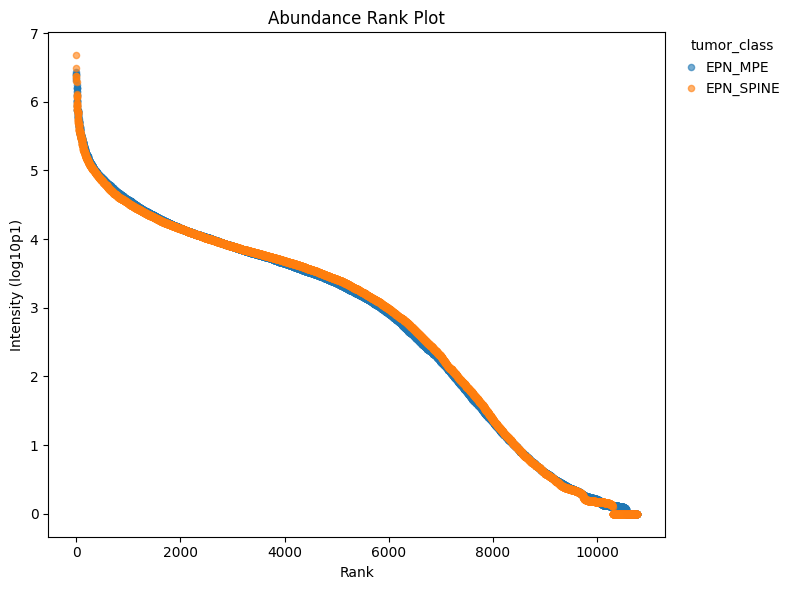

In [9]:
pr.pl.abundance_rank(adata, color='tumor_class')

> 📝 *Your turn*: Compare the curves of the two tumor classes and interpret the plot.

<details>
<summary>Answer</summary>

Both curves span roughly 4–6 orders of magnitude on the log-intensity axis — the expected dynamic range of a healthy DIA experiment. The shape is the classic "knee" of a proteome: a small number of very abundant proteins at the top of the rank, a shallow plateau through the bulk, and a long tail of low-abundance proteins approaching the detection limit.

The two class curves overlap almost entirely. That tells us there is no systemic intensity bias between the groups — neither class has run substantially "hotter" or "colder" on the instrument — so any downstream group difference we find is unlikely to be a global loading / total-signal artefact. If one curve sat noticeably above the other we would suspect a normalization issue and re-check loading or LC-MS conditions before trusting differential abundance.

</details>

#### Sample-wise protein coverage

Number of proteins quantified per sample is a direct readout of run quality. Samples that identify many fewer proteins than their peers usually had a failed digestion, low loading, or instrument issues and will introduce noise downstream. We drop any sample below `min_count=4000`.

/home/ifichtner/repositories/proteopy/main/proteopy/pl/stats.py:1468: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


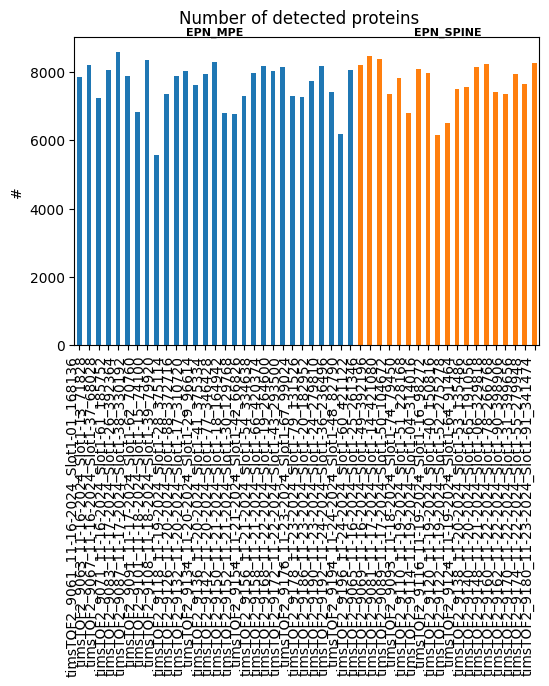

<Axes: ylabel='#'>

In [10]:
pr.pl.n_proteins_per_sample(
    adata,
    zero_to_na=True,
    order_by='tumor_class',
)

In [11]:
pr.pp.filter_samples(
    adata,
    min_count=4000,
    zero_to_na=True,
)

0 obs removed


#### Protein-wise completeness filtering

For each protein, we ask: *in what fraction of samples was it quantified?* Proteins measured in only a handful of samples cannot support a meaningful group comparison and contribute mostly imputation noise. We keep proteins seen in **≥ 80 %** of samples.

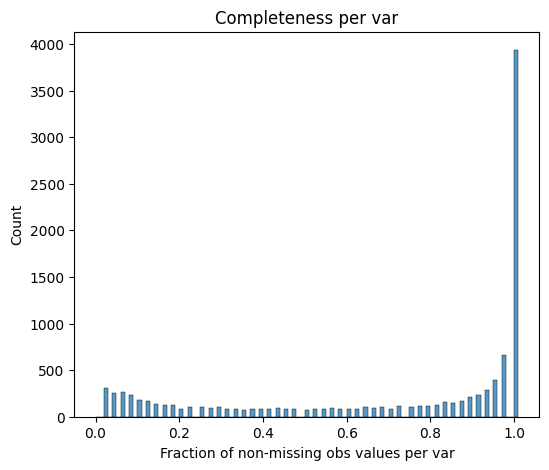

<Axes: title={'center': 'Completeness per var'}, xlabel='Fraction of non-missing obs values per var', ylabel='Count'>

In [12]:
pr.pl.completeness_per_var(adata, zero_to_na=True)

> 📝 *Your turn*: What fraction of proteins are quantified in *all* samples? What about the long tail of nearly-missing proteins? Justify the choice of `min_fraction=0.8` — what would change at 0.95?

<details>
<summary>Answer</summary>

The completeness distribution is **bimodal**: a tall spike near 1.0 (proteins quantified in essentially every sample — the reliable "core" of the proteome, typically around half of all features), a long flat shoulder in the middle, and a second spike near 0 (proteins seen in only a few runs — the noisy tail dominated by stochastic detection at the limit).

`min_fraction=0.8` keeps the core plus the well-measured shoulder, while removing the near-empty tail that contributes mostly imputation noise to downstream statistics. Roughly 4–5k of ~10k proteins are dropped here.

Pushing to `min_fraction=0.95` would be safer statistically but biologically more conservative: it would discard proteins missing from even a single sample's run, including biologically interesting low-abundance proteins that happen to fall below LOQ in one or two samples. We would lose hundreds to a couple of thousand additional features for relatively little gain in robustness. `0.8` is a common, pragmatic middle ground for cohort-scale DIA; tighten it only if you suspect imputation is driving your downstream results.

</details>

In [13]:
pr.pp.filter_var_completeness(adata, min_fraction=0.8, zero_to_na=True)

4441 var removed


#### Within-group coefficient of variation

The coefficient of variation (CV = SD / mean) per protein within each group measures technical reproducibility. Most proteins should sit well below the 50 % reference line; a long tail above it indicates noisy quantification and is a red flag for the group's data quality.

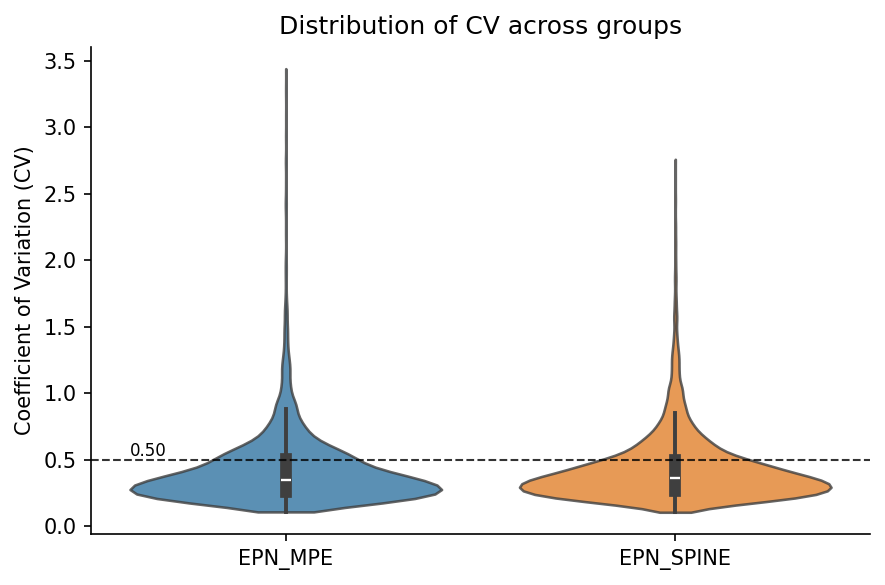

In [14]:
pr.pl.cv_by_group(
    adata,
    group_by="tumor_class",
    min_samples=3,
    hline=0.5,
)

> 📝 *Your turn*: Compare the CV distributions of the two groups. Is one noticeably noisier? Where does the bulk of each distribution sit relative to the 50 % reference line?

<details>
<summary>Answer</summary>

The bulk of both distributions sits well below the 50 % line — typical median CVs are in the 10–25 % range, which is what we expect for well-behaved DIA quantification with MaxLFQ. Most proteins are reproducibly measured within each tumor class.

Both groups look broadly similar in shape; neither is obviously noisier than the other. A small tail of proteins stretches above the 50 % line in each group — these are the highly variable features (often low-abundance proteins close to the detection limit, or biologically heterogeneous markers within the class). They are not a red flag for the group as a whole, but they are precisely the kind of feature that should be looked at twice if it shows up in a differential-abundance hit list.

If one group's distribution had a much fatter tail or a higher median, we would suspect a within-group quality issue (mixed batches, outlier sample driving variance) and revisit that group's sample list before running statistics.

</details>

### Log transform

Most parametric statistical tests (t-test, ANOVA, linear models) assume **normally distributed** observations and **homoscedasticity** — variance that does not depend on the mean. Raw MS intensities violate both: they are approximately **log-normal**, and their noise scales with intensity (*heteroscedastic*: more abundant proteins are noisier on the linear scale).

A log2 transform fixes both problems at once: log-normal becomes roughly normal, and the multiplicative, intensity-dependent noise becomes additive and roughly constant across the dynamic range (*variance stabilization*). As a bonus, differences on the log2 scale read directly as fold-changes — a difference of 1 is a 2× change.

We keep the raw intensities in `adata.layers['raw']` so we can revisit them later if needed.

In [15]:
# Convert zeros to NaN and log2 transform
adata.layers["raw"] = adata.X.copy()
adata.X[adata.X == 0] = np.nan
adata.X = np.log2(adata.X)

### Median normalization

Even after careful sample preparation, total signal varies between runs for technical reasons (loading amount, instrument response, column condition). **Median normalization** centers every sample's log-intensities on a common median, removing a multiplicative shift while leaving relative differences between proteins within a sample intact.

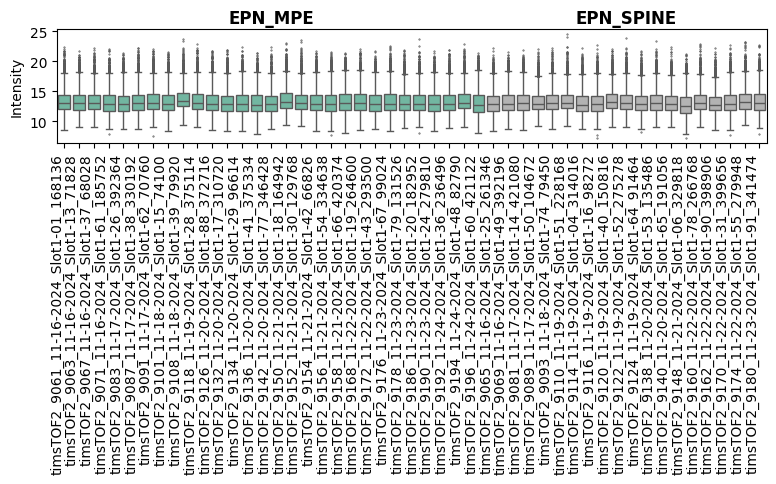

<Axes: ylabel='Intensity'>

In [16]:
# Intensity boxplot before normalization
pr.pl.intensity_box_per_sample(
    adata,
    order_by="tumor_class",
    zero_to_na=True,
)

In [17]:
pr.pp.normalize_median(adata, log_space=True)

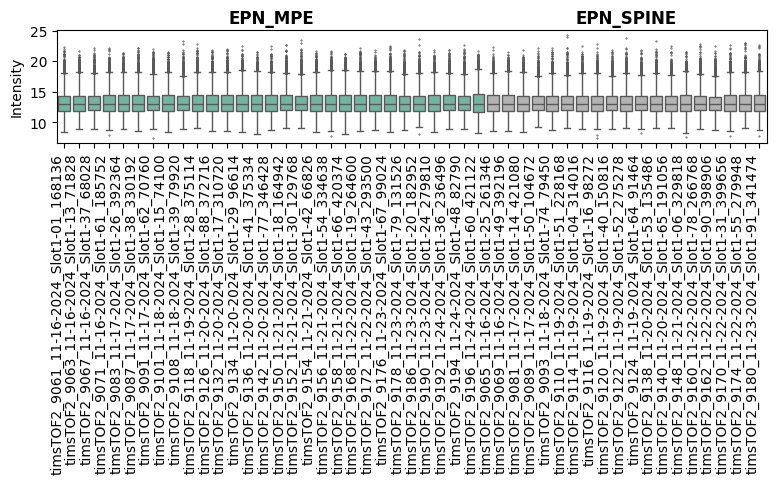

<Axes: ylabel='Intensity'>

In [18]:
# Intensity boxplot before normalization
pr.pl.intensity_box_per_sample(
    adata,
    order_by="tumor_class",
    zero_to_na=True,
)

> 📝 *Your turn*: Compare the boxplot above with the one before `pr.pp.normalize_median`. What changed? Did the within-sample spread change?

<details>
<summary>Answer</summary>

The **medians of all samples are now aligned on the same horizontal line** — before normalization each sample's box sat at a slightly different height (some samples were globally more intense, others less). After median normalization those vertical offsets are gone.

The **within-sample spread (IQR, whiskers) is essentially unchanged**. This is exactly what median normalization is meant to do: it subtracts a per-sample constant in log-space (equivalent to dividing by a per-sample scaling factor on the linear scale), which removes a multiplicative loading / instrument-response bias *without* touching the relative ranking of proteins within a sample.

If a single sample showed a much wider spread than the others, normalization would *not* fix that — it indicates a quality problem (incomplete digestion, contamination, low-quality run) that needs to be handled by sample filtering, not normalization.

</details>

### Missing value imputation

Missing values are pervasive in DIA proteomics — a protein can be missing because it really is absent, or because its signal fell below the detection limit ("missing not at random", MNAR). Pretending they are zero distorts statistics; dropping them throws away signal.

The **downshift imputation** strategy, popularized by the [Perseus software](https://maxquant.net/perseus/) and the Cox lab, replaces missing values with draws from a Gaussian that is shifted *down* relative to each sample's measured distribution (here: 1.8 standard deviations below the mean, with a width of 0.3 SD). The intuition is that an unseen protein is most likely just below the detection limit — so we impute it there, with some random spread to avoid creating an artificial spike.

> 🔍 *Dig deeper*: read the [Perseus documentation on missing-value imputation](https://cox-labs.github.io/coxdocs/replacemissingfromgaussian.html) and consider when MNAR vs. MAR assumptions are appropriate. The histogram below colours imputed values so you can sanity-check the result.

In [19]:
pr.pp.impute_downshift(
    adata,
    downshift=1.8,
    width=0.3,
    zero_to_na=True,
    random_state=123,
    verbose=True,
)

Measured: 294,837 values (97.1%)
Imputed: 8,763 values (2.9%)


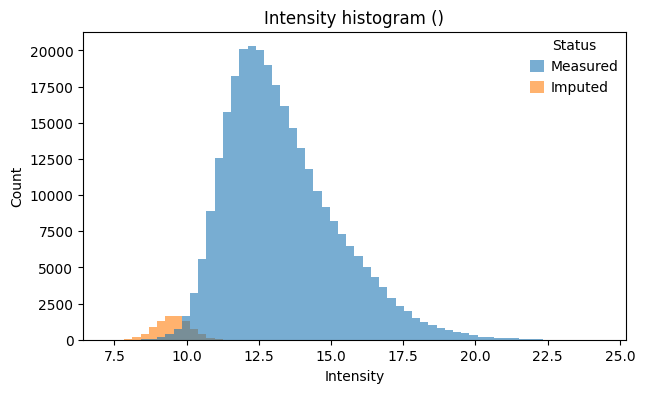

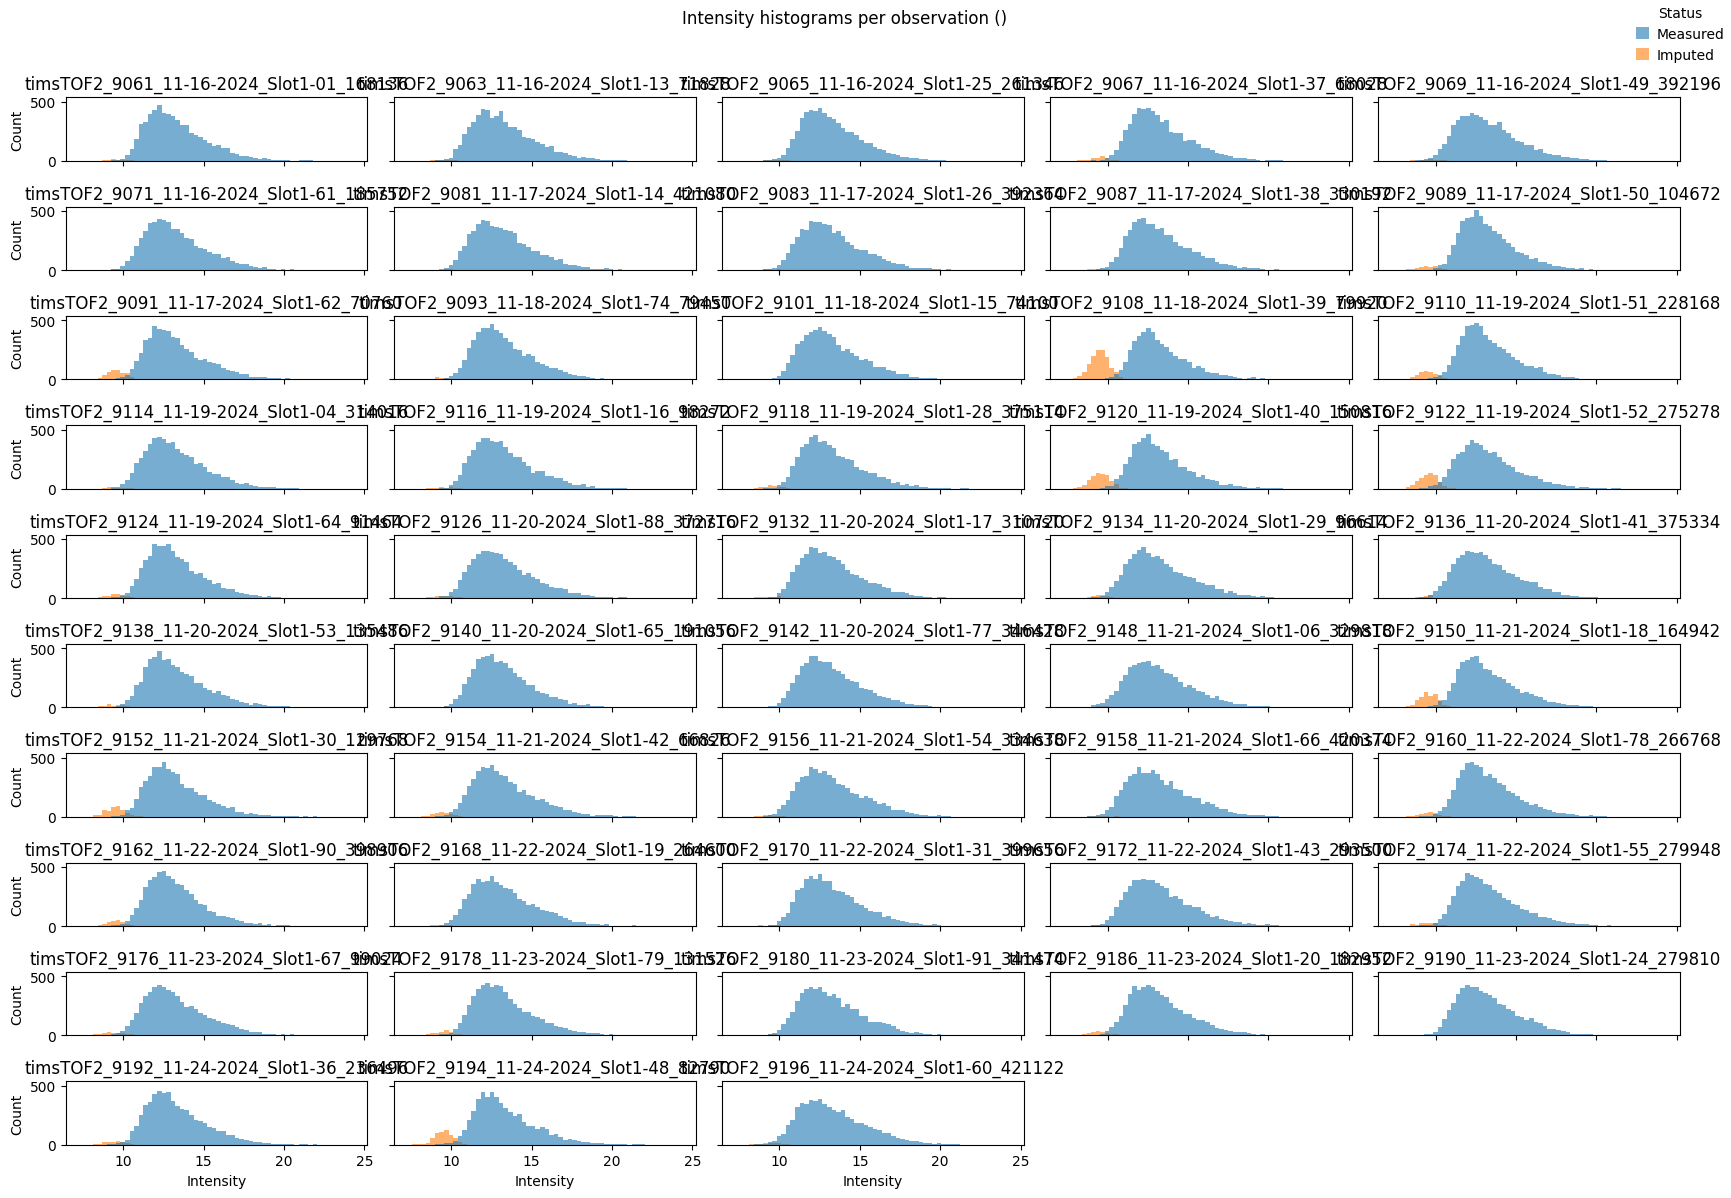

In [20]:
# Combined histogram across all samples
pr.pl.intensity_hist(
    adata,
    color_imputed=True,
    density=False,
)

# Per-sample histograms (small multiples)
pr.pl.intensity_hist(
    adata,
    color_imputed=True,
    per_obs=True,
    ncols=5,
    legend_loc="upper right",
    density=False,
    figsize=(17, 12),
)

> 📝 *Your turn*: Where do the imputed values sit relative to the measured ones? Does the downshifted Gaussian fall in a plausible region for 'below detection limit', or does it overlap with the measured distribution? How does imputation differ between samples?

<details>
<summary>Answer</summary>

In the combined histogram, the imputed values form a **small secondary peak in the left tail** of the intensity distribution — roughly 1.8 standard deviations below each sample's mean. That is the "below detection limit" region: just under where the measured signal starts to fall off, but not so far below that the imputed values are biologically absurd. There is a small overlap with the lower end of the measured distribution, which is intentional — completely separating the two would create an artificial gap and make any t-test pick up "imputed vs. measured" rather than real biology.

In the per-sample panels you can see that **the downshift is sample-specific**: each sample's imputed peak is positioned relative to *its own* mean and SD, not a global one. A sample with a lower overall intensity distribution gets a lower imputation peak; a sample with a wider distribution gets a wider imputation peak. This preserves the per-sample structure that median normalization just put in place.

A useful sanity check is the fraction printed by `pr.pp.impute_downshift` — here ~2.8 % of values were imputed. If that number creeps above ~10–15 % you should worry, because then imputation, not measurement, is shaping a non-trivial fraction of your matrix and the MNAR assumption starts to look much shakier.

</details>

## Exploratory data analysis

Before any statistical model, we look at the data to understand the sources of variation: do replicates cluster together? Do tumor classes separate? Are there outlier samples? We use a sample-sample correlation heatmap, PCA, and UMAP as complementary views.

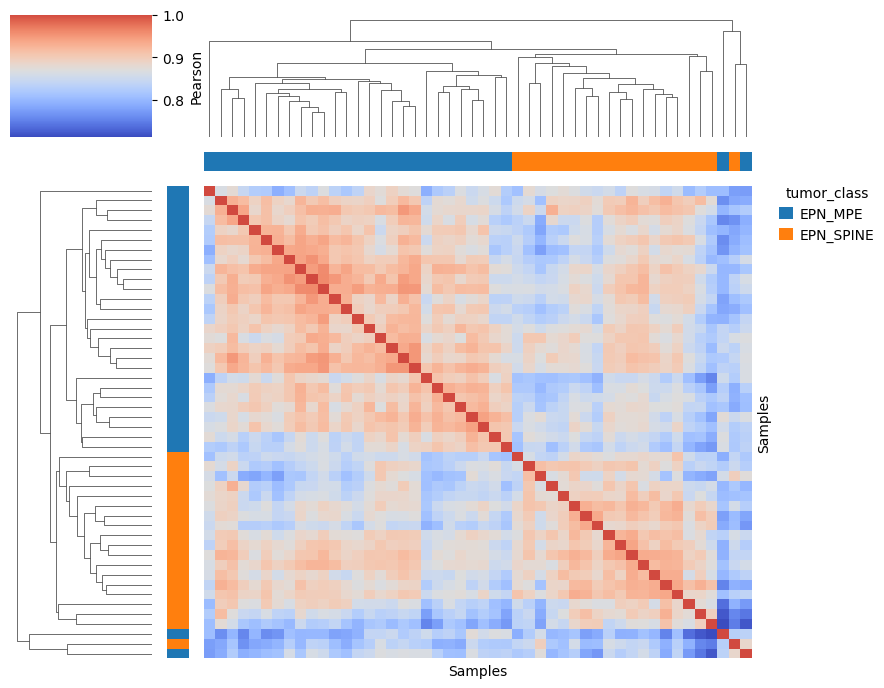

In [21]:
pr.pl.sample_correlation_matrix(
    adata,
    margin_color="tumor_class",
)

> 📝 *Your turn*: Do samples of the same tumor class cluster together? Are there any obvious outliers correlating poorly with the rest?

<details>
<summary>Answer</summary>

The heatmap shows clear **block structure along the diagonal** that lines up with the tumor-class margin annotation — samples of the same class correlate more strongly with each other (typically Pearson *r* ≳ 0.9) than with samples of the other class. That is the first non-trivial sign that there is a real biological signal separating the two groups, before we have done any statistics.

Look for any single sample that shows uniformly *low* correlation with **everyone else, including members of its own class** — that is the outlier signature (single light row/column cutting through the heatmap). Here the correlations within class are high and homogeneous, so we have no obvious sample to drop.

If you did find an outlier, the next steps would be: (a) check its protein count and CV — was it already borderline at the QC stage? (b) cross-reference its acquisition / preparation metadata (not loaded in this trimmed annotation file, but worth re-querying from the LIMS) — is it from a different batch? (c) decide whether to drop it or to add the batch as a covariate.

</details>

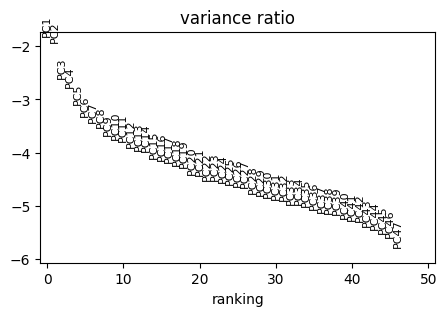

... storing 'tumor_class' as categorical
... storing 'group3' as categorical


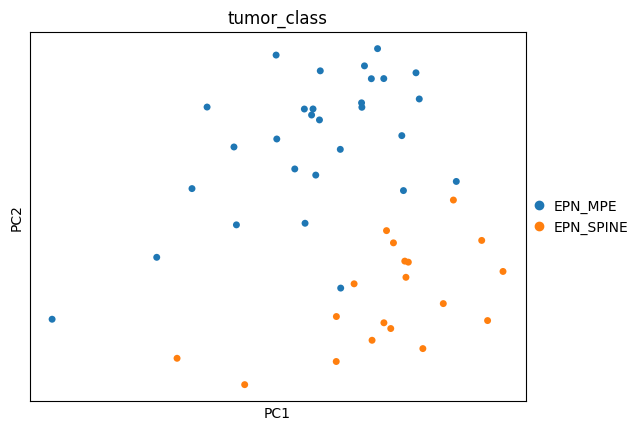

In [22]:
sc.tl.pca(adata)
with rc_context({"figure.figsize": (5, 3)}):
    sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

sc.pl.pca(
    adata,
    color="tumor_class",
    dimensions=(0, 1),
    ncols=2,
    size=100,
)

> 📝 *Your turn*: Does PC1 separate tumor classes? How much variance do the first few PCs explain? Is it reasonable to stop at PC2 or should we look further?

<details>
<summary>Answer</summary>

PC1 carries most of the between-class signal — the two tumor classes are clearly displaced from each other along PC1, even though some within-class spread remains along PC2. That is the textbook expectation when the dominant biological axis of variation in your data is the comparison you actually care about, and it is a strong sign that the differential-abundance test downstream will find biologically meaningful hits.

The variance-ratio (scree) plot shows the typical proteomics decay: PC1 captures ~15–25 % of the variance, PC2 another ~10 %, and then a long tail of small components. The first two together explain on the order of a quarter to a third of the total variance — enough to give a meaningful 2D summary, but **not** the whole story.

Stopping at PC2 is fine for *visualizing* class separation, but you should glance at PC3–PC5 (e.g. via `sc.pl.pca(adata, color='tumor_class', dimensions=[(2,3),(3,4)])`) before drawing conclusions. Sometimes a sub-structure (sex, batch, tumor subtype) only appears on PC3 or PC4 and can warn you about a confounder that PC1/PC2 hides.

</details>

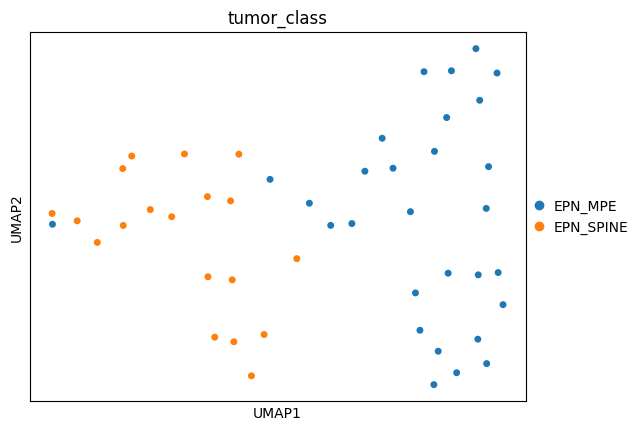

In [23]:
sc.pp.neighbors(adata, n_neighbors=3)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="tumor_class",
    size=100,
)

> 📝 *Your turn*: Does UMAP separate the tumor classes more clearly than PCA? UMAP preserves local structure — what could small sub-clusters within a class represent?

<details>
<summary>Answer</summary>

UMAP usually shows a **crisper** separation than PCA on the same data, because it is a non-linear embedding that pulls similar samples tightly together and pushes dissimilar ones apart. Here the two tumor classes form two visibly distinct islands, often with no overlap between them.

The flip side of that crispness is that UMAP **distances are not interpretable as distances in the original feature space**: the white space between two clusters does not tell you "how different" they are, only that the algorithm chose to separate them. So do not read "the EPN_MPE cluster is twice as far from EPN_SPINE as in PCA" as a biological statement.

The little sub-clusters inside a class can represent several things, in rough order of plausibility:

1. **Biological substructure** — molecular subtypes within a tumor class, anatomical sub-location (e.g. cervical vs. lumbar spinal ependymoma), grade.
2. **Technical structure** — different sample-preparation batches or MS acquisition dates. With the trimmed annotation file used here (only `sample_id` + `tumor_class`) we cannot check this directly; if it matters in your own analysis, re-merge the relevant batch metadata into `adata.obs` and re-colour the UMAP.

Whichever it is, this is exactly the kind of structure that **the differential-abundance t-test will average over** if you do not account for it — so it is worth identifying before running statistics.

</details>

> 💻 *Code it*: UMAPs are a 2D representation of higher-dimensional data. The `n_neighbors` parameter controls the **local-vs-global trade-off**: small values pin the layout to very local structure, larger values pull it toward the global geometry.
>
> Rerun `sc.pp.neighbors` and `sc.tl.umap` with several different `n_neighbors` values (e.g. 2, 5, 10, 15, 30) and re-plot. How does the embedding change? Do the tumor classes separate more cleanly at any particular value?

/home/ifichtner/miniforge3/envs/pp-usage_main/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


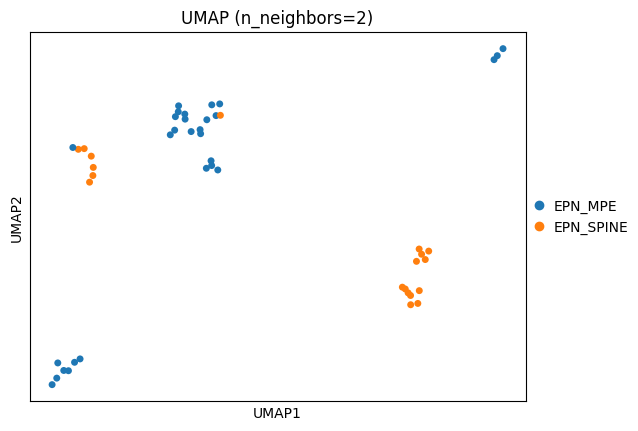

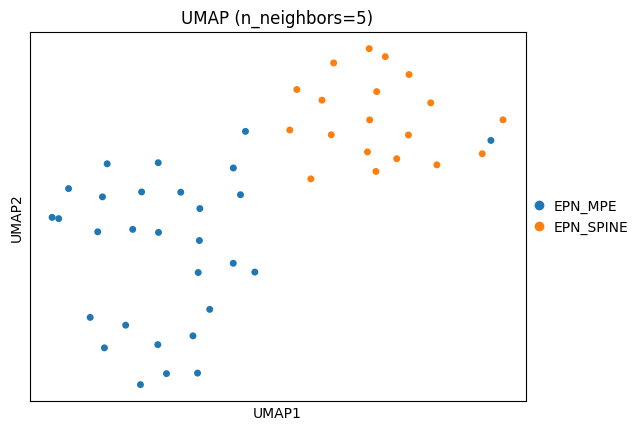

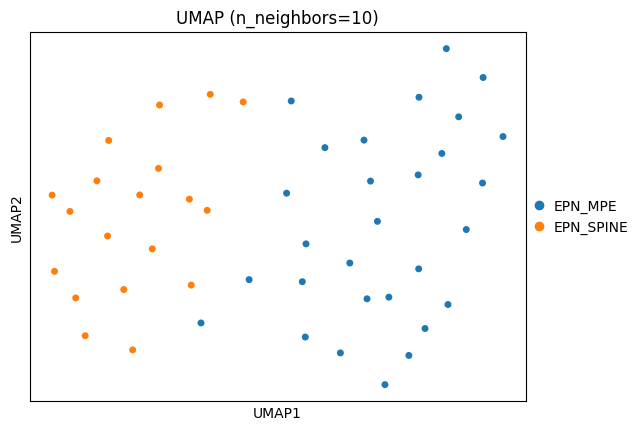

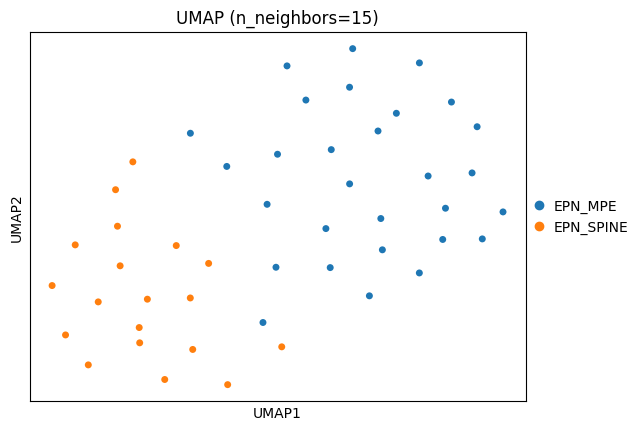

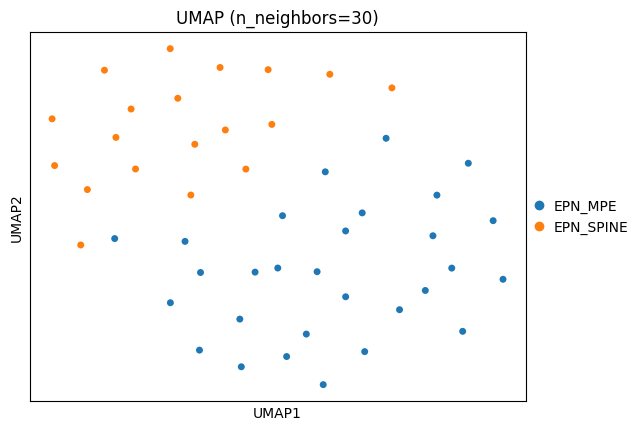

In [24]:
for n_neighbors in [2, 5, 10, 15, 30]:
    sc.pp.neighbors(adata, n_neighbors=n_neighbors)
    sc.tl.umap(adata)
    sc.pl.umap(
        adata,
        color="tumor_class",
        size=100,
        title=f"UMAP (n_neighbors={n_neighbors})",
    )

## Differential protein abundance

We now ask: *which proteins differ between two tumor classes?* Here we compare myxopapillary ependymoma of the spine (`EPN_MPE`) with non-myxopapillary spinal ependymoma (`EPN_SPINE`). We use a two-sample t-test in log-space and adjust p-values with Benjamini–Hochberg (BH) to control the false discovery rate. The volcano plot summarizes effect size (log2 fold change) against statistical significance.

Per-protein results are stored under `adata.varm[...]` keyed by the test design, and can be pulled out as a tidy data frame with `pr.get.differential_abundance_df`.

In [25]:
pr.tl.differential_abundance(
    adata,
    method="ttest_two_sample",
    group_by="tumor_class",
    setup={"group1": "EPN_MPE", "group2": "EPN_SPINE"},
    multitest_correction="bh",
    alpha=0.01,
    space="log",
)

Saved test results in .varm['ttest_two_sample;tumor_class;EPN_MPE_vs_EPN_SPINE']


In [26]:
pr.get.tests(adata)

,key,key_group,test_type,group_by,design,design_label,design_mode,layer
0,ttest_two_sample;tumor_class;EPN_MPE_vs_EPN_SPINE,ttest_two_sample;tumor_class;one_vs_one,ttest_two_sample,tumor_class,EPN_MPE_vs_EPN_SPINE,EPN MPE vs EPN SPINE,one_vs_one,None


In [27]:
dpa = pr.get.differential_abundance_df(
    adata,
    keys='ttest_two_sample;tumor_class;EPN_MPE_vs_EPN_SPINE',
    sort_by='pval_adj',
)
dpa['gene_id'] = dpa['var_id'].map(adata.var['Genes'].to_dict())

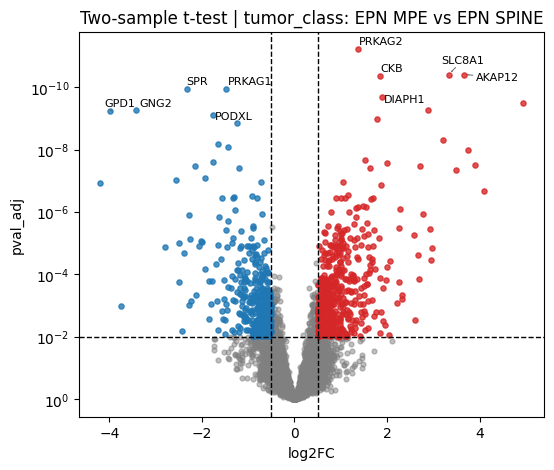

<Axes: title={'center': 'Two-sample t-test | tumor_class: EPN MPE vs EPN SPINE'}, xlabel='log2FC', ylabel='pval_adj'>

In [28]:
pr.pl.volcano(
    adata,
    varm_slot="ttest_two_sample;tumor_class;EPN_MPE_vs_EPN_SPINE",
    fc_thresh=0.5,
    pval_thresh=0.01,
    top_labels=5,
    alt_labels_key="Genes",
    xlabel="log2FC",
    ylabel="pval_adj",
)

> 📝 *Your turn*: How many proteins pass the dual significance + fold-change threshold? What are the top hits?

<details>
<summary>Answer</summary>

The code cell below counts them programmatically. Expect on the order of a few hundred proteins to pass the joint threshold (`|logfc| > 0.5` and adjusted *p* < 0.01), split roughly evenly between "up in EPN_MPE" and "up in EPN_SPINE" — the exact numbers depend on imputation seed and filtering.

Among the strongest hits you should see metabolic / signaling proteins such as **PRKAG2** / **PRKAG1** (AMPK subunits — energy sensing), **CKB** (creatine kinase, brain isoform), **GPD1** (glycerol-3-phosphate dehydrogenase), and structural / extracellular proteins such as **AKAP12**, **SPR**, **PODXL**, **IGFBP5**. PRKAG2 and CKB up-regulation in particular is consistent with a more energy-demanding, neuronally-differentiated phenotype in `EPN_MPE`.

Treat the top hits as **hypotheses, not conclusions** — the next step (gene-set enrichment) tells you whether these single-protein hits actually fit a coherent biological story or just look striking in isolation.

</details>

In [29]:
fc_thresh = 0.5
pval_thresh = 0.01

sig = dpa[(dpa["pval_adj"] < pval_thresh) & (dpa["logfc"].abs() > fc_thresh)]

print(f"Significant proteins (|logfc| > {fc_thresh} & pval_adj < {pval_thresh}): {len(sig)}")
print(f"  up in EPN_MPE:   {(sig['logfc'] > 0).sum()}")
print(f"  up in EPN_SPINE: {(sig['logfc'] < 0).sum()}")

print("\nTop 10 hits by adjusted p-value:")
sig.head(10)[["gene_id", "logfc", "tstat", "pval", "pval_adj"]]

Significant proteins (|logfc| > 0.5 & pval_adj < 0.01): 791
  up in EPN_MPE:   445
  up in EPN_SPINE: 346

Top 10 hits by adjusted p-value:


,gene_id,logfc,tstat,pval,pval_adj
0,PRKAG2,1.375385,11.981231,9.582863e-16,6.061161e-12
1,SLC8A1,3.335663,11.111136,1.284407e-14,3.914961e-11
2,AKAP12,3.654979,10.990164,1.856899e-14,3.914961e-11
3,CKB,1.848790,10.857115,2.791261e-14,4.413681e-11
4,SPR,-2.310136,-10.452599,9.773123e-14,1.133861e-10
5,PRKAG1,-1.469254,-10.421940,1.075599e-13,1.133861e-10
6,DIAPH1,1.899903,10.188181,2.242108e-13,2.025905e-10
7,CA3,4.935553,10.002455,4.038596e-13,3.193015e-10
8,GNG2,-3.430862,-9.787166,8.031503e-13,5.245313e-10
9,IGFBP5,2.890393,9.777176,8.292984e-13,5.245313e-10


### Set enrichment analysis using Decoupler

Lists of differentially abundant proteins are hard to interpret on their own. **Gene-set enrichment analysis (GSEA)** asks a question at a higher level: *is a predefined set of biologically related genes systematically up- or down-regulated in our comparison?* Instead of looking at single proteins, we look at coordinated shifts across whole pathways or signatures.

Three closely related methods you should know:

- **ORA** (Over-Representation Analysis): take the top-N significant genes, ask whether any pathway is enriched among them with a hypergeometric / Fisher test. Simple, but throws away the ranking and is sensitive to your significance cutoff.
- **GSEA** (Gene Set Enrichment Analysis, Subramanian et al. 2005): rank *all* genes by a statistic (e.g. the t-statistic), then test whether members of a pathway concentrate at the top or bottom of the ranked list. No arbitrary cutoff, uses the full signal.
- **GSVA** (Gene Set Variation Analysis): turns the gene × sample matrix into a pathway × sample matrix in an *unsupervised* way, useful for downstream clustering or per-sample pathway activity.

[`decoupler`](https://decoupler.readthedocs.io/) is a unified Python package that implements ORA, GSEA, GSVA and many other enrichment methods under a common API, and ships convenient access to curated gene-set databases via `dc.op` (the Omnipath bridge). We use it here to run GSEA against MSigDB.

Find the decoupler documentation [here](https://decoupler.readthedocs.io/en/latest/api/generated/decoupler.mt.gsea.html).

**MSigDB** — the [Molecular Signatures Database](https://www.gsea-msigdb.org/gsea/msigdb) — is the canonical collection of gene sets curated by the Broad Institute. It groups tens of thousands of gene sets into *collections* (hallmark pathways, canonical pathways such as Reactome/KEGG, GO terms, chemical and genetic perturbations, immunologic signatures, oncogenic signatures, cell-type markers, miRNA / TF target sets, etc.). The collection name appears in the `collection` column above.

In [30]:
dc.op.show_resources()

,name,license
0,Adhesome,commercial
1,Almen2009,commercial
2,Baccin2019,academic
3,CORUM_Funcat,academic
4,CORUM_GO,academic
...,...,...
76,iTALK,academic
77,kinase.com,non_profit
78,scConnect,commercial
79,scConnect_complex,commercial


In [31]:
msig_db = dc.op.resource(
    name='MSigDB',
    organism='human',
    license='academic',
)

map = {
    'geneset': 'source',
    'genesymbol': 'target',
}
msig_db = msig_db.rename(columns=map)

msig_db = msig_db.drop_duplicates(subset=['source', 'target'])
msig_db

,target,collection,source
,,,
0,A1BG,reactome_pathways,REACTOME_HEMOSTASIS
1,A1BG,go_cellular_component,GOCC_PLATELET_ALPHA_GRANULE_LUMEN
2,A1BG,chemical_and_genetic_perturbations,CHENG_IMPRINTED_BY_ESTRADIOL
3,A1BG,immunesigdb,GSE13522_WT_VS_IFNG_KO_SKING_T_CRUZI_Y_STRAIN_...
4,A1BG,immunesigdb,GSE25088_CTRL_VS_IL4_AND_ROSIGLITAZONE_STIM_MA...
...,...,...,...
5895457,ZZZ3,mirna_targets_mirdb,MIR656_3P
5895458,ZZZ3,mirna_targets_mirdb,MIR513B_5P
5895459,ZZZ3,mirna_targets_mirdb,MIR449C_5P


In [32]:
tstats = dpa[['gene_id', 'tstat']].set_index('gene_id').drop_duplicates().T
tstats

gene_id,PRKAG2,SLC8A1,AKAP12,CKB,SPR,PRKAG1,DIAPH1,CA3,GNG2,IGFBP5,...,NFKB2,CBLL1,PAPSS1,DHX8,SH3BGRL,ECI1,THUMPD1,DERL2,POLD2,RPAP3
tstat,11.981231,11.111136,10.990164,10.857115,-10.452599,-10.42194,10.188181,10.002455,-9.787166,9.777176,...,-0.003478,0.001527,0.001447,-0.001527,-0.001306,-0.001205,-0.001622,-0.001447,0.001608,0.000558


In [33]:
nes_scores, pval_adj = dc.mt.gsea(tstats, net=msig_db, tmin=3)

pval_adj = pval_adj.T.clip(2.22e-16, 1).T
mask = (pval_adj.T < 0.1).iloc[:, 0]
nes_scores = nes_scores.loc[:, mask]
pval_adj = pval_adj.loc[:, mask]

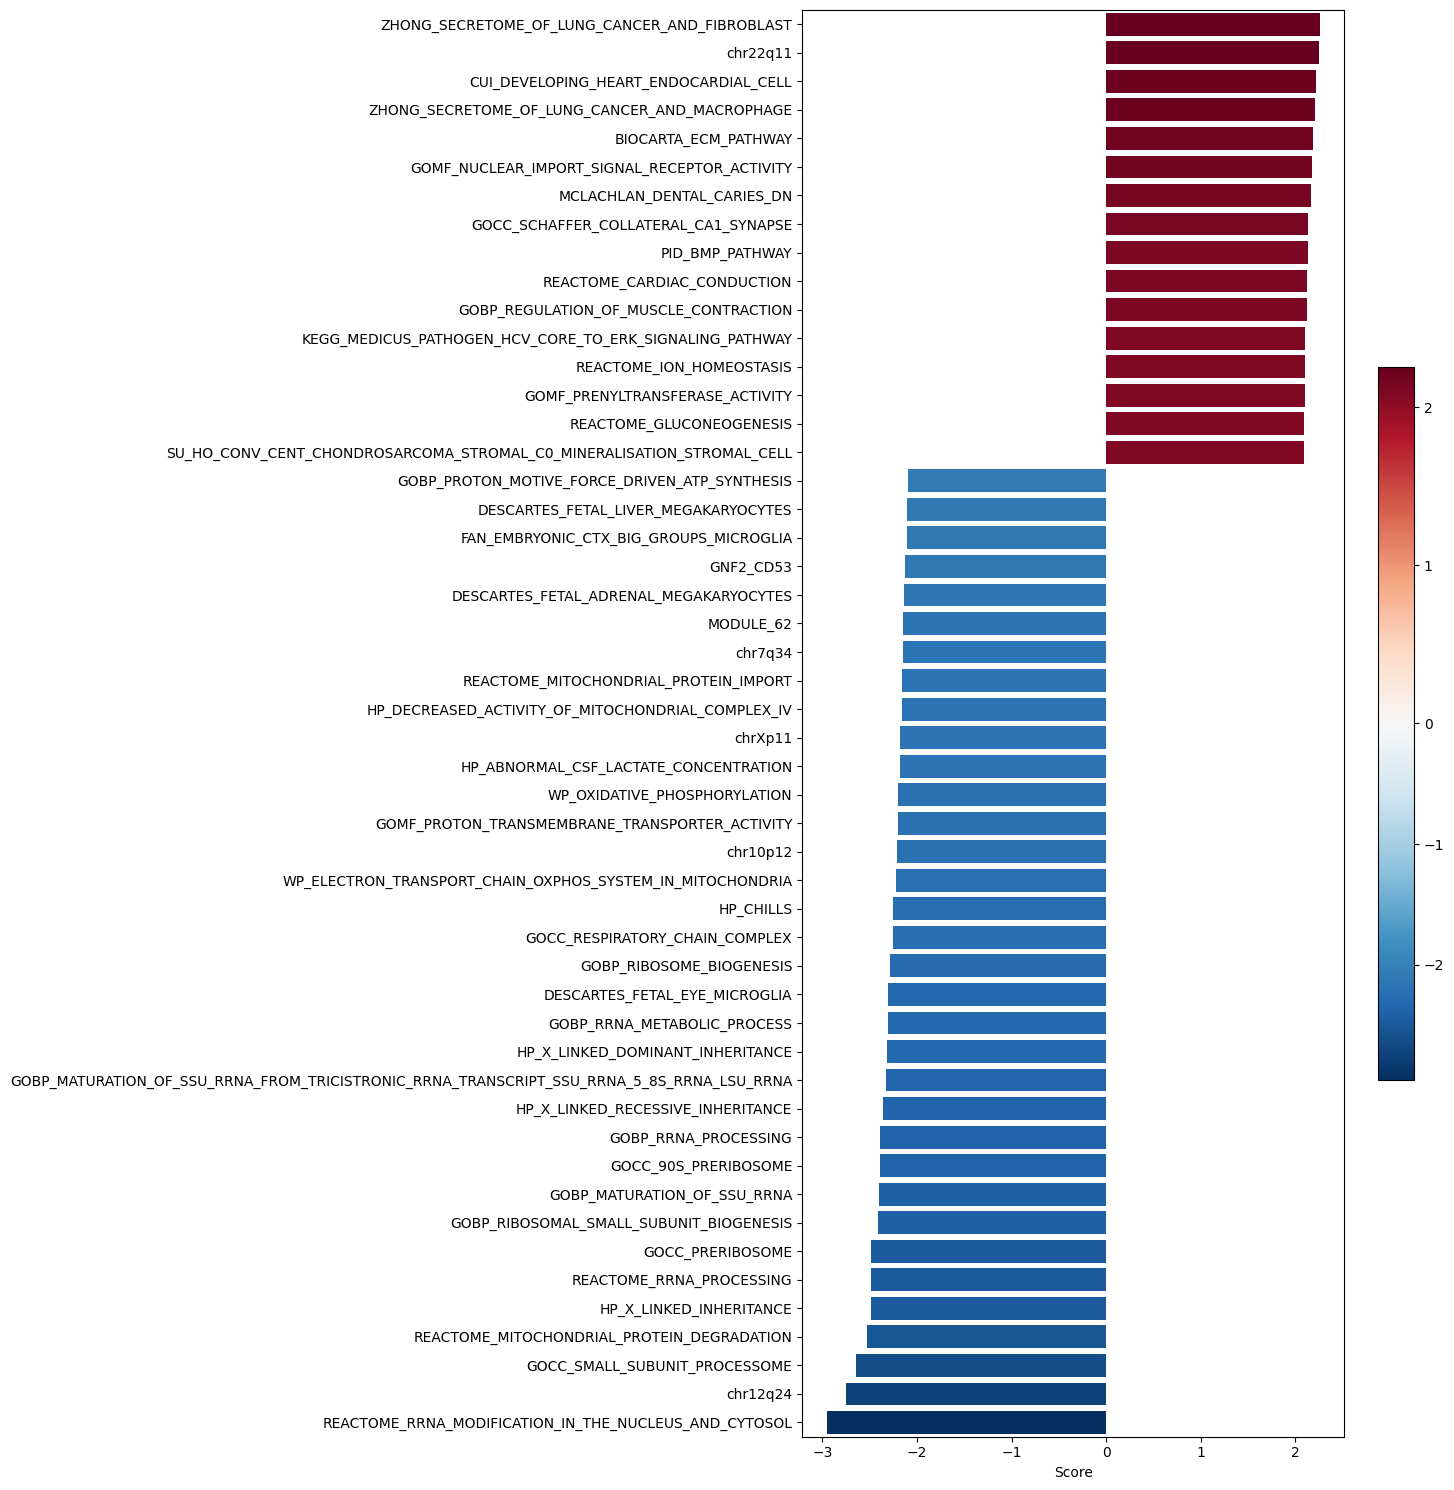

In [34]:
dc.pl.barplot(
    data=nes_scores,
    name='tstat',
    top=50,
    figsize=(15,15),
)

> 📝 *Your turn*: Pick two or three biological themes from the top pathways. Do any make immediate sense for spinal vs. myxopapillary ependymoma?

<details>
<summary>Answer</summary>

A few themes that typically come out of this comparison:

- **Energy / metabolism** — AMPK signaling, glycolysis / oxidative phosphorylation, creatine metabolism (driven by PRKAG2, CKB, GPD1). Myxopapillary ependymoma is histologically distinct from other spinal ependymomas and has been described to show a more metabolically active, *neuronally differentiated* phenotype, which fits.
- **Extracellular matrix / adhesion** — collagen, basement-membrane and proteoglycan gene sets. MPE is named after its characteristic *myxoid* extracellular matrix, so a strong ECM signal in the MPE-up direction is biologically expected and is a good positive control that the analysis is finding something real.
- **Neuronal differentiation / synaptic** — gene sets related to axon guidance, neurofilaments, synaptic vesicle proteins. Again consistent with MPE being more "differentiated" than its grade-II/III spinal counterparts.
- **Cell-cycle / proliferation** — Reactome cell cycle, E2F / MYC targets. These often go in the *opposite* direction (higher in `EPN_SPINE`) because non-MPE spinal ependymomas are typically more proliferative.

Two or three plausible, biologically consistent themes are exactly what a good enrichment result looks like. If the top pathways were dominated by unrelated cancers or by very generic terms ("translation", "ribosome") you should be more skeptical — see the methodological-flaw discussion below.

</details>

leading edge: ['ALDH2' 'OXSM' 'SLC25A5' 'MICU2' 'HSD17B10']


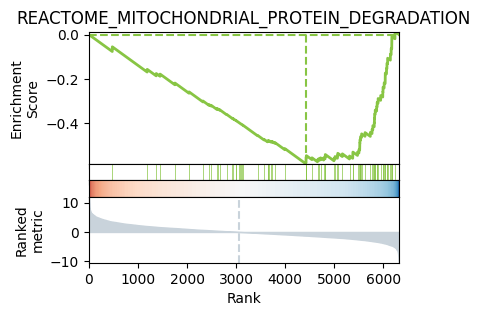

In [35]:
_, le = dc.pl.leading_edge(
    dpa.set_index('gene_id'),
    stat="tstat",
    net=msig_db,
    name="REACTOME_MITOCHONDRIAL_PROTEIN_DEGRADATION",
)
print("leading edge:", le[:5])

> 📝 *Your turn*: How do you interpret the plot? Pick one or two leading-edge genes for a pathway of interest and look them up. Do they have a known role in ependymoma or in the relevant biological process?

<details>
<summary>Answer</summary>

The leading-edge plot has two parts: a **running enrichment score** (the green curve) plotted along the ranked gene list, and **tick marks** showing where the genes of the chosen gene set sit in that ranking. The *leading edge* is everything between the start of the ranked list and the position where the running score reaches its extremum — these are the genes that *drive* the enrichment signal for this particular pathway, not just members of it.

For `REACTOME_MITOCHONDRIAL_PROTEIN_DEGRADATION`, the leading edge typically contains mitochondrial proteases and chaperones such as **LONP1**, **CLPP**, **CLPX**, **HSPD1**, **HSPE1**, **AFG3L2** — the machinery that maintains mitochondrial proteostasis. Elevated mitochondrial protein turnover in `EPN_MPE` fits the broader picture of a more metabolically active, neuronally differentiated tumor.

Worked example for one gene:

- **LONP1** is a major ATP-dependent mitochondrial matrix protease responsible for degrading oxidatively damaged or unfolded mitochondrial proteins. It is up-regulated in cells with high mitochondrial activity and has been reported as a tumor-context-dependent factor in several cancers (over-expression supports tumor cell survival under metabolic stress; loss triggers proteotoxic stress).
- In the ependymoma context, an MPE-up signal for LONP1 + CLPP + HSPD1 is consistent with the metabolic/neuronal-differentiation theme that the higher-level pathway plots already suggested — it is a multi-layer confirmation, not a new story.

Pick one or two leading-edge genes, look them up in [UniProt](https://www.uniprot.org) or [GeneCards](https://www.genecards.org), and ask: does this gene's known function match the pathway label, and does the direction of regulation (up in MPE vs. up in SPINE) match what you'd predict biologically? If yes, the enrichment hit becomes much more credible than the raw NES score on its own.

</details>

### 🧠 Task — what's wrong with this picture?

Before we summarize, take a moment and think:

> **What is the central methodological flaw in applying GSEA (as implemented above using MSigDB as reference gene set database) directly to a DIA-NN protein-level result?**

<details>
<summary>Hint:</summary>
Look closely at the `Genes` column of `adata.var` and at the `target` column of `msig_db`. What are the units in each? What happens when a single DIA-NN row corresponds to a **protein group** containing several proteins, each mapping to its own gene symbol? And what about a protein whose `Genes` field contains `GENEA;GENEB`?
</details>

Discuss with your neighbour:

1. How does our `tstats` table currently treat protein groups that map to multiple genes?
2. How does MSigDB treat the same gene appearing in different contexts?
3. What would a more rigorous mapping look like? (Keywords to look up: *peptide-centric* vs. *protein-centric* enrichment, *protein-group ambiguity*, *gene-symbol mapping*.)

<details>
<summary>Solution:</summary>

The flaw is a **units mismatch between what MS quantifies and what MSigDB indexes**.

- **MSigDB is gene-centric.** Each gene set is a list of unique gene symbols (`target` column). Membership is binary: a gene is either in the set or it isn't.
- **DIA-NN quantifies protein groups, not genes.** A *protein group* is a set of proteins that share peptide evidence and cannot be told apart by MS alone. The `Genes` field for one protein group can therefore be:
  - **Empty** — no annotated gene → the row contributes nothing to GSEA.
  - **A single gene** — clean case.
  - **A semicolon-separated list** (e.g. `HLA-A;HLA-B;HLA-C`) — one quantitative value, several genes. In the code above we pass the raw string as the index, so the *string* `"HLA-A;HLA-B;HLA-C"` never matches any MSigDB target and is silently dropped — quantitative signal lost.
  - **A gene that also appears in another protein group** (paralogs, isoforms, shared peptides between gene families) — the same gene receives multiple, possibly conflicting, t-statistics. `drop_duplicates()` in the `tstats` line keeps only the first one it sees, arbitrarily discarding the rest.

So our `tstats` table is **neither truly gene-level nor truly protein-level**: ambiguous groups are dropped, multi-gene rows are dropped as un-mappable strings, and duplicates are resolved by row order rather than by any biological criterion.

**What a more rigorous mapping looks like:**

1. **Split multi-gene `Genes` fields** on `;` and either (a) duplicate the t-statistic to each gene, or (b) drop ambiguous groups entirely and report how many were lost.
2. **Aggregate when a gene receives multiple t-statistics**: take the median, or the value with the largest absolute t-statistic — but make the rule explicit, don't let `drop_duplicates()` decide for you.
3. **Report the mapping quality**: how many protein groups mapped 1-to-1 to a gene, how many were dropped, how many were many-to-one? A clean GSEA result on a badly-mapped table is worse than no result.
4. **Consider protein-centric resources**: e.g. CORUM (complexes), Reactome at the UniProt level, or PROGENy / DoRothEA via `decoupler` — these can be queried with protein/UniProt IDs and avoid the gene-mapping step entirely.

The take-home: **enrichment is only as trustworthy as the identifier translation that precedes it.** Always look at the dropped rows.

</details>

## Summary — what you have learned

Working through this notebook, you have:

- **Read a DIA-NN `report.parquet`** and filtered it on three complementary FDR statistics before pivoting to a sample × protein matrix.
- Met the **`proteopy` + `AnnData`** data model and seen how submodules (`pr.read` / `pp` / `pl` / `tl` / `get`) map cleanly onto analysis stages.
- Performed **quality control**: contaminant removal (Frankenfield 2022), low-coverage sample filtering, and completeness-based protein filtering.
- Applied a standard **preprocessing pipeline**: log2 transform → median normalization → downshift imputation (Perseus-style) for MNAR missing values.
- Explored the data with **sample correlation, PCA, and UMAP**.
- Computed **differential protein abundance** with a two-sample t-test and BH correction, and visualized it with a volcano plot.
- Run **gene-set enrichment (GSEA)** with `decoupler` against MSigDB, inspected the top pathways with bar- and dot-plots, and examined the **leading edge** to see which genes drive the enrichment.

You have also seen the conceptual limits: MS proteomics quantifies **protein groups**, not genes, and translating between the two — for gene-set enrichment in particular — is a step that requires care.

**Where to go next**

- Swap GSEA for ORA (`dc.mt.ora`) or GSVA (`dc.mt.gsva`) and compare the top hits.
- Replace MSigDB with a more focused resource (Reactome, PROGENy, DoRothEA) via `dc.op.resource(...)`.
- Read the [`proteopy`](https://proteopy.readthedocs.io/) and [`decoupler`](https://decoupler.readthedocs.io/) documentation for the full set of tools.

In [ ]:
!pip freeze

adjustText==1.3.0
anndata==0.11.4
anyio==4.13.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array-api-compat==1.14.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.14.3
biopython==1.87
bleach==6.3.0
certifi==2026.5.20
cffi==2.0.0
charset-normalizer==3.4.7
comm==0.2.3
contourpy==1.3.2
cycler==0.12.1
dcor==0.7
debugpy==1.8.20
decorator==5.3.1
decoupler==2.1.4
defusedxml==0.7.1
docrep==0.3.2
et_xmlfile==2.0.0
exceptiongroup==1.3.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.63.0
formulaic==1.2.1
formulaic-contrasts==1.0.0
fqdn==1.5.1
h11==0.16.0
h5py==3.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.15
igraph==1.0.0
interface_meta==2.0.1
ipykernel==7.2.0
ipython==8.39.0
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.20.0
Jinja2==3.1.6
joblib==1.5.3
json5==0.14.0
jsonpointer==3.1.1
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter-events==0.12.1
jupyter-lsp==2.3.1
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==